<a href="https://colab.research.google.com/github/belleasi/Machine-Learning-models/blob/main/semi-supervised/%20%20self_training_breast_cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

SELF-TRAINING - SEMI-SUPERVISED LEARNING

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  wors

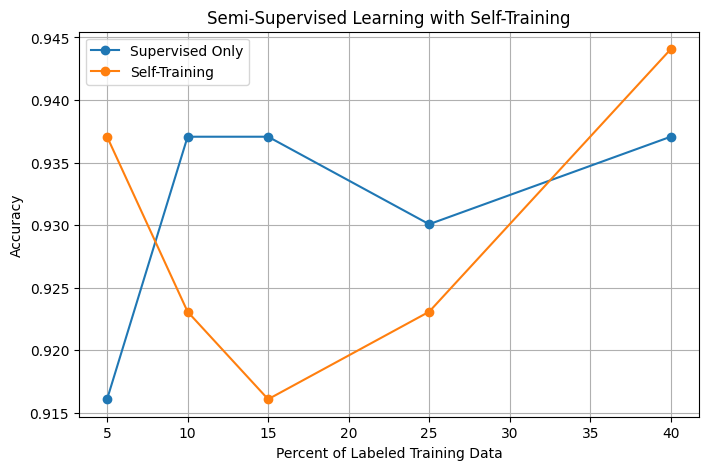


This model belongs in the semi-supervised folder.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.semi_supervised import SelfTrainingClassifier

np.random.seed(42)

print("=" * 60)
print("SELF-TRAINING - SEMI-SUPERVISED LEARNING")
print("=" * 60)

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

df = pd.DataFrame(X, columns=data.feature_names)

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nTarget names:")
print(data.target_names)

# Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Create semi-supervised labels
# Keep only 15% of labels, hide the rest as -1
y_train_partial = np.full_like(y_train, -1)

labeled_percent = 0.15
num_labeled = int(labeled_percent * len(y_train))

labeled_indices = np.random.choice(
    len(y_train),
    size=num_labeled,
    replace=False
)

y_train_partial[labeled_indices] = y_train[labeled_indices]

print("\nTotal training samples:", len(y_train))
print("Labeled training samples:", num_labeled)
print("Unlabeled training samples:", len(y_train) - num_labeled)

# Supervised baseline using only labeled data
supervised_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

supervised_model.fit(
    X_train[labeled_indices],
    y_train[labeled_indices]
)

supervised_pred = supervised_model.predict(X_test)
supervised_acc = accuracy_score(y_test, supervised_pred)

print("\nSupervised-only accuracy:")
print(supervised_acc)

# Semi-supervised model using self-training
base_classifier = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

self_training_model = SelfTrainingClassifier(
    estimator=base_classifier,
    threshold=0.80,
    max_iter=10
)

self_training_model.fit(X_train, y_train_partial)

semi_pred = self_training_model.predict(X_test)
semi_acc = accuracy_score(y_test, semi_pred)

print("\nSelf-training accuracy:")
print(semi_acc)

print("\nClassification report:")
print(classification_report(y_test, semi_pred, target_names=data.target_names))

# Compare different labeled percentages
percentages = [0.05, 0.10, 0.15, 0.25, 0.40]
supervised_scores = []
semi_scores = []

for percent in percentages:
    y_partial = np.full_like(y_train, -1)
    n_labeled = int(percent * len(y_train))

    idx = np.random.choice(
        len(y_train),
        size=n_labeled,
        replace=False
    )

    y_partial[idx] = y_train[idx]

    # Supervised only
    rf_supervised = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    rf_supervised.fit(X_train[idx], y_train[idx])
    acc_supervised = accuracy_score(y_test, rf_supervised.predict(X_test))

    # Self-training
    rf_base = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    semi_model = SelfTrainingClassifier(
        estimator=rf_base,
        threshold=0.80,
        max_iter=10
    )

    semi_model.fit(X_train, y_partial)
    acc_semi = accuracy_score(y_test, semi_model.predict(X_test))

    supervised_scores.append(acc_supervised)
    semi_scores.append(acc_semi)

    print(f"\n{int(percent * 100)}% labeled data")
    print("Supervised-only:", acc_supervised)
    print("Self-training:", acc_semi)

# Visualization
plt.figure(figsize=(8, 5))
plt.plot(
    [p * 100 for p in percentages],
    supervised_scores,
    marker="o",
    label="Supervised Only"
)

plt.plot(
    [p * 100 for p in percentages],
    semi_scores,
    marker="o",
    label="Self-Training"
)

plt.title("Semi-Supervised Learning with Self-Training")
plt.xlabel("Percent of Labeled Training Data")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("\nThis model belongs in the semi-supervised folder.")